# Solar Panel Data Analysis
## Tracking Panel (Device 1) vs Fixed Panel (Device 2)

This notebook loads your battery data files and compares the two setups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load all data files that have actual data
data_files = sorted([f for f in os.listdir('.') if f.startswith('BatteryDat_') and f.endswith('.txt')])
print(f"Found {len(data_files)} files: {data_files}")

Found 6 files: ['BatteryDat_13.txt', 'BatteryDat_14.txt', 'BatteryDat_15.txt', 'BatteryDat_16.txt', 'BatteryDat_28.txt', 'BatteryDat_48.txt']


In [2]:
# Load and separate Device 1 (tracking) vs Device 2 (fixed) from each file
# The data alternates rows: odd rows = Device 1, even rows = Device 2

all_data = {}

for f in data_files:
    try:
        # Read raw, skip header
        raw = pd.read_csv(f, header=None, skiprows=1)
        if len(raw) < 2:
            print(f"  {f}: empty or too small, skipping")
            continue
        
        cols = ['BatV', 'BatI', 'BatEn', 'PanelV', 'PanelP', 'Hours']
        raw.columns = cols[:len(raw.columns)]
        
        # Split into Device 1 (odd rows) and Device 2 (even rows)
        dev1 = raw.iloc[0::2].reset_index(drop=True).copy()
        dev2 = raw.iloc[1::2].reset_index(drop=True).copy()
        
        file_num = f.split('_')[1].split('.')[0]
        duration_hrs = raw['Hours'].max()
        
        all_data[file_num] = {'dev1': dev1, 'dev2': dev2, 'filename': f}
        
        print(f"  {f}: {len(dev1)} readings per device, {duration_hrs:.2f} hours")
    except Exception as e:
        print(f"  {f}: error - {e}")

print(f"\nLoaded {len(all_data)} files successfully")

  BatteryDat_13.txt: 249 readings per device, 0.69 hours
  BatteryDat_14.txt: 154 readings per device, 0.43 hours
  BatteryDat_15.txt: 496 readings per device, 1.38 hours
  BatteryDat_16.txt: 1086 readings per device, 3.01 hours
  BatteryDat_28.txt: error - No columns to parse from file
  BatteryDat_48.txt: 34 readings per device, 0.02 hours

Loaded 5 files successfully


## Quick Look at the Data
What does a typical reading look like?

In [3]:
# Preview the first file's data
first_key = list(all_data.keys())[0]
print(f"=== File {first_key} - Device 1 (Tracking Panel) ===")
print(all_data[first_key]['dev1'].head(5))
print(f"\n=== File {first_key} - Device 2 (Fixed Panel) ===")
print(all_data[first_key]['dev2'].head(5))
print(f"\n=== Summary Stats - Device 1 ===")
print(all_data[first_key]['dev1'].describe().round(2))

=== File 13 - Device 1 (Tracking Panel) ===
    BatV  BatI  BatEn  PanelV  PanelP   Hours
0  12.40  0.54   0.01   19.69    43.0  0.0002
1  12.39  0.49   0.01   18.95    43.0  0.0031
2  12.39  0.45   0.01   20.05    42.0  0.0059
3  12.39  0.42   0.01   19.29    42.0  0.0087
4  12.40  0.48   0.01   19.26    42.0  0.0114

=== File 13 - Device 2 (Fixed Panel) ===
    BatV  BatI  BatEn  PanelV  PanelP   Hours
0  13.44  3.31   0.01   19.10    45.0  0.0002
1  13.45  3.31   0.01   19.47    45.0  0.0031
2  13.45  3.24   0.01   20.35    45.0  0.0059
3  13.44  3.21   0.01   19.43    44.0  0.0087
4  13.44  3.17   0.01   19.89    43.0  0.0114

=== Summary Stats - Device 1 ===
         BatV    BatI   BatEn  PanelV  PanelP   Hours
count  249.00  249.00  249.00  249.00  249.00  249.00
mean    12.53    1.02    0.01   19.04   49.49    0.34
std      0.07    0.69    0.01    1.04    9.10    0.20
min     12.29   -2.30   -0.03   14.00    7.00    0.00
25%     12.47    0.82    0.01   18.83   46.00    0.17
50% 

## Panel Power Over Time — Tracking vs Fixed
The big question: does the tracking panel make more power?

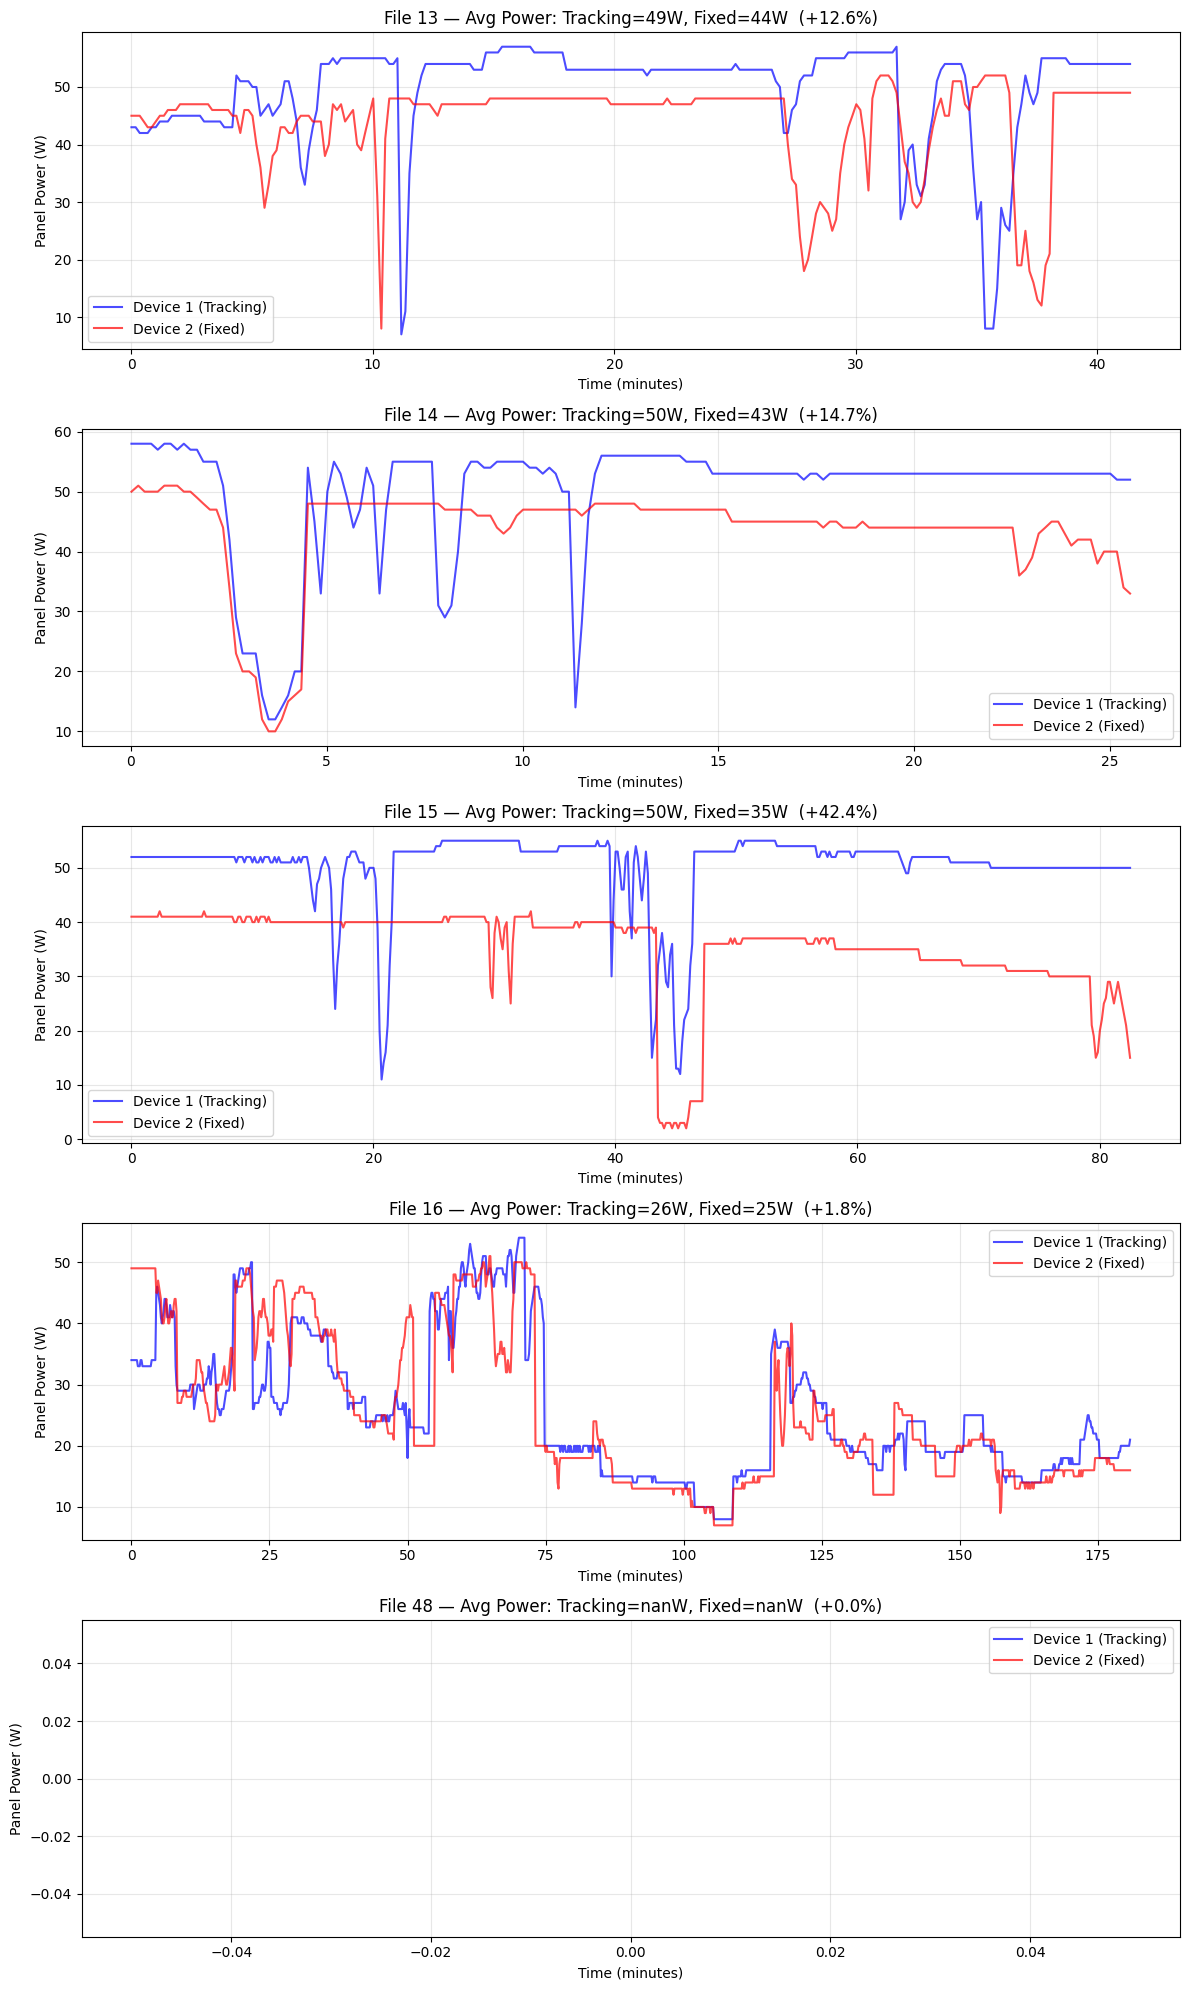

In [4]:
# Panel Power over time — side by side comparison
fig, axes = plt.subplots(len(all_data), 1, figsize=(12, 4 * len(all_data)), squeeze=False)

for i, (key, data) in enumerate(all_data.items()):
    ax = axes[i, 0]
    d1, d2 = data['dev1'], data['dev2']
    
    # Convert hours to minutes for readability
    ax.plot(d1['Hours'] * 60, d1['PanelP'], 'b-', alpha=0.7, label='Device 1 (Tracking)')
    ax.plot(d2['Hours'] * 60, d2['PanelP'], 'r-', alpha=0.7, label='Device 2 (Fixed)')
    
    avg1 = d1['PanelP'].mean()
    avg2 = d2['PanelP'].mean()
    advantage = ((avg1 - avg2) / avg2) * 100 if avg2 > 0 else 0
    
    ax.set_title(f"File {key} — Avg Power: Tracking={avg1:.0f}W, Fixed={avg2:.0f}W  ({advantage:+.1f}%)", fontsize=12)
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('Panel Power (W)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Battery Voltage Over Time
Higher voltage = more charged. Watch how the batteries behave during the day.

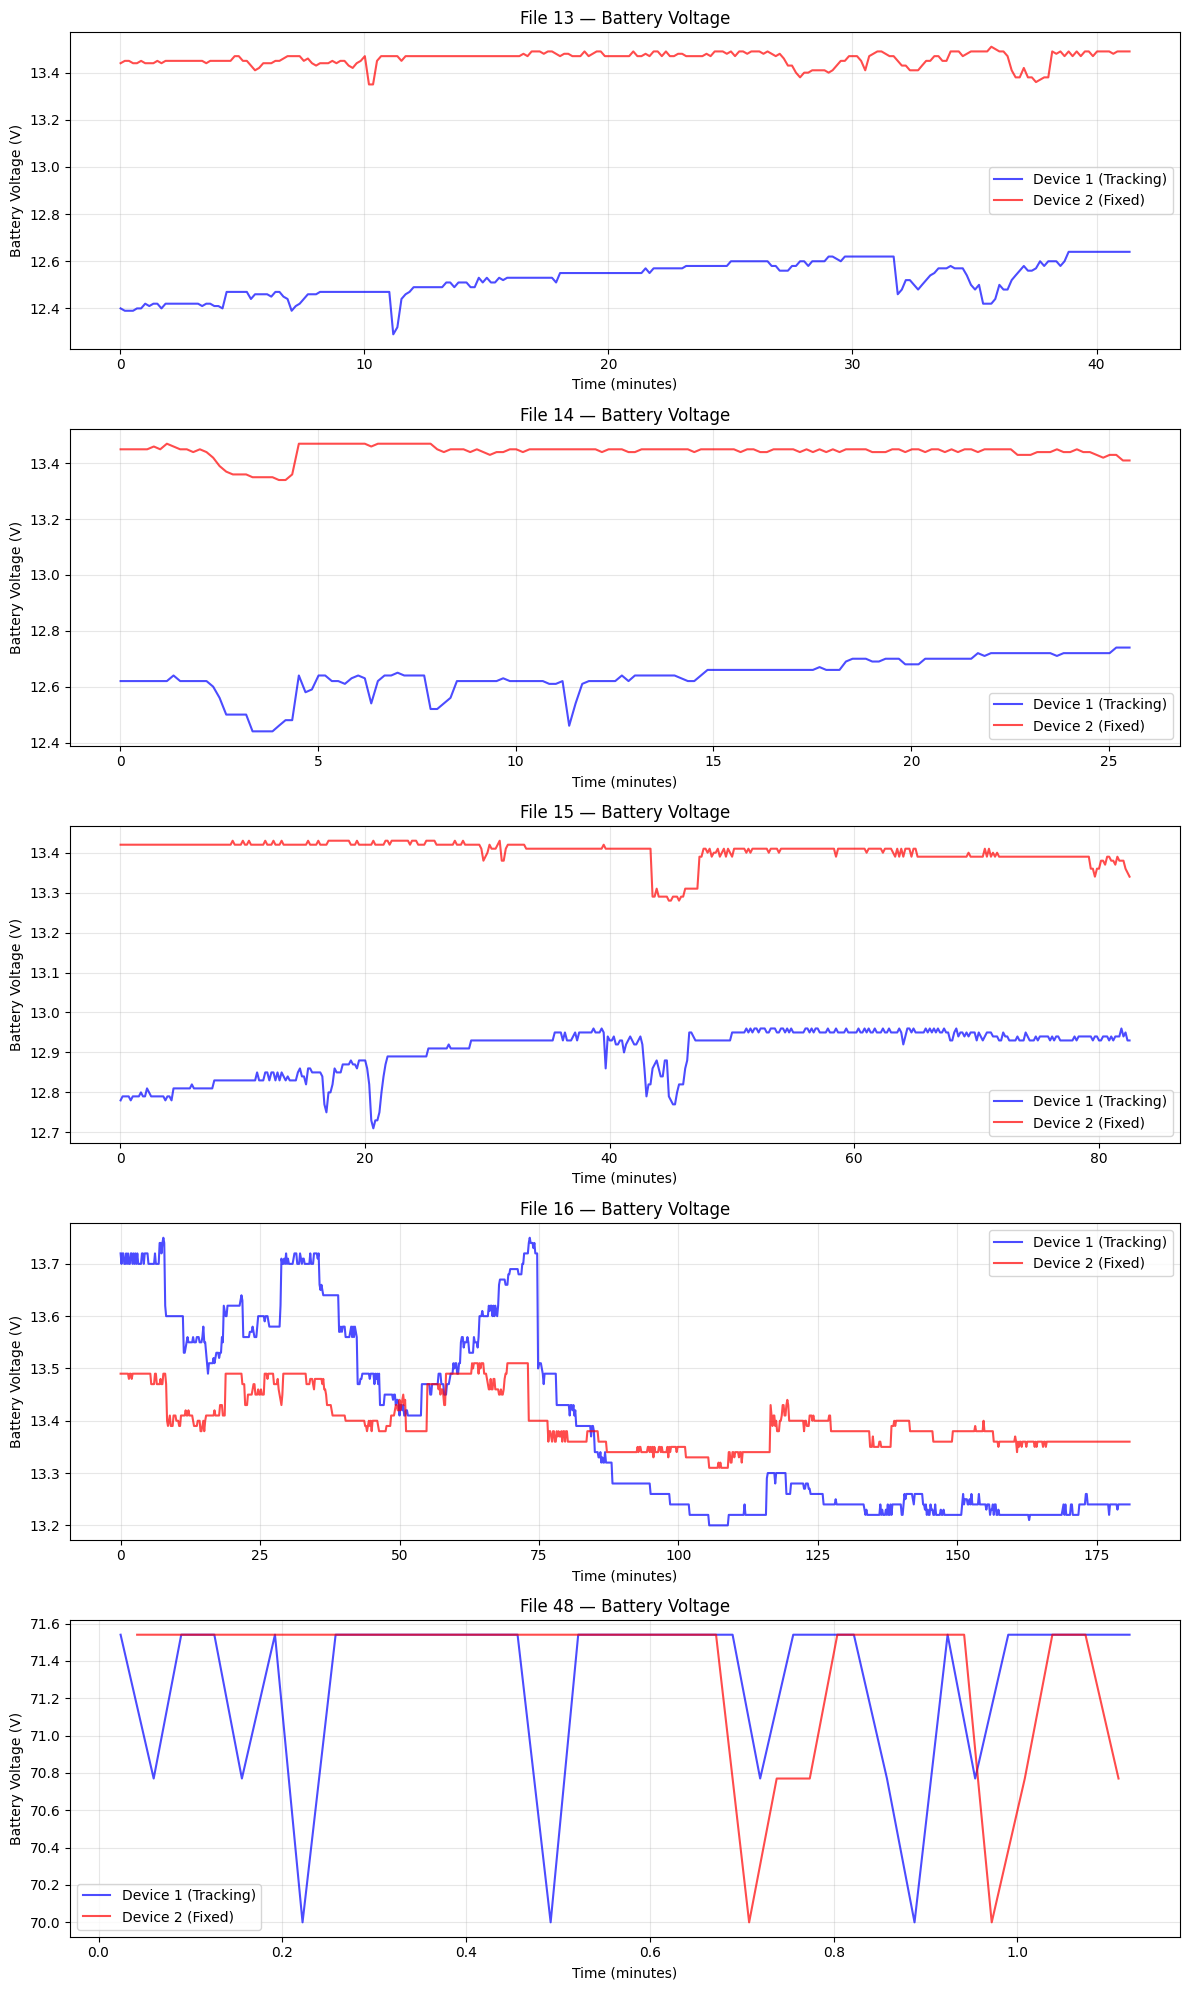

In [5]:
# Battery Voltage over time
fig, axes = plt.subplots(len(all_data), 1, figsize=(12, 4 * len(all_data)), squeeze=False)

for i, (key, data) in enumerate(all_data.items()):
    ax = axes[i, 0]
    d1, d2 = data['dev1'], data['dev2']
    
    ax.plot(d1['Hours'] * 60, d1['BatV'], 'b-', alpha=0.7, label='Device 1 (Tracking)')
    ax.plot(d2['Hours'] * 60, d2['BatV'], 'r-', alpha=0.7, label='Device 2 (Fixed)')
    
    ax.set_title(f"File {key} — Battery Voltage", fontsize=12)
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('Battery Voltage (V)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Total Energy Comparison
How much total energy did each setup produce across all recording sessions?

File  Duration (hrs)  Tracking Energy (Wh)  Fixed Energy (Wh)  Tracking Advantage (%)  Avg Tracking Power (W)  Avg Fixed Power (W)
  13            0.69                  34.5               30.6                    12.6                    49.5                 44.0
  14            0.43                  21.5               18.7                    14.7                    49.8                 43.5
  15            1.38                  69.8               49.0                    42.4                    50.3                 35.3
  16            3.01                  78.5               77.1                     1.8                    25.8                 25.4
  48            0.02                   0.0                0.0                     0.0                     NaN                  NaN


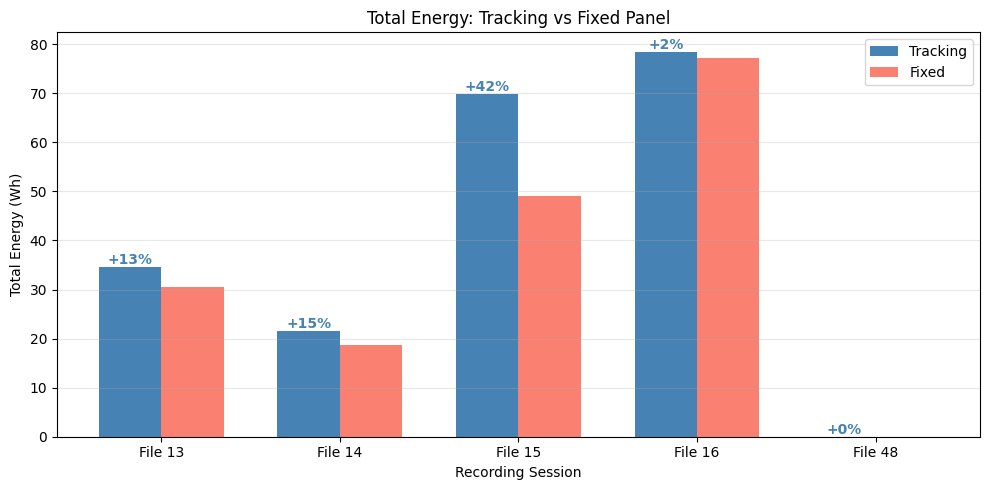

In [6]:
# Total energy produced per file (Power × Time)
# Energy = integral of power over time ≈ sum of (power × time_step)

summary_rows = []

for key, data in all_data.items():
    d1, d2 = data['dev1'], data['dev2']
    
    # Time step in hours between readings
    dt1 = d1['Hours'].diff().median()
    dt2 = d2['Hours'].diff().median()
    
    # Energy in Watt-hours = Power(W) × time(hours)
    energy1 = (d1['PanelP'] * dt1).sum()
    energy2 = (d2['PanelP'] * dt2).sum()
    
    duration = d1['Hours'].max()
    advantage = ((energy1 - energy2) / energy2) * 100 if energy2 > 0 else 0
    
    summary_rows.append({
        'File': key,
        'Duration (hrs)': round(duration, 2),
        'Tracking Energy (Wh)': round(energy1, 1),
        'Fixed Energy (Wh)': round(energy2, 1),
        'Tracking Advantage (%)': round(advantage, 1),
        'Avg Tracking Power (W)': round(d1['PanelP'].mean(), 1),
        'Avg Fixed Power (W)': round(d2['PanelP'].mean(), 1),
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(summary))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], summary['Tracking Energy (Wh)'], width, label='Tracking', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], summary['Fixed Energy (Wh)'], width, label='Fixed', color='salmon')

ax.set_xlabel('Recording Session')
ax.set_ylabel('Total Energy (Wh)')
ax.set_title('Total Energy: Tracking vs Fixed Panel')
ax.set_xticks(x)
ax.set_xticklabels([f"File {r}" for r in summary['File']])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, row in summary.iterrows():
    ax.annotate(f"+{row['Tracking Advantage (%)']:.0f}%", 
                xy=(i - width/2, row['Tracking Energy (Wh)']),
                ha='center', va='bottom', fontweight='bold', color='steelblue')

plt.tight_layout()
plt.show()

## Correlation Heatmap
Which measurements move together? Strong correlations tell us what drives performance.

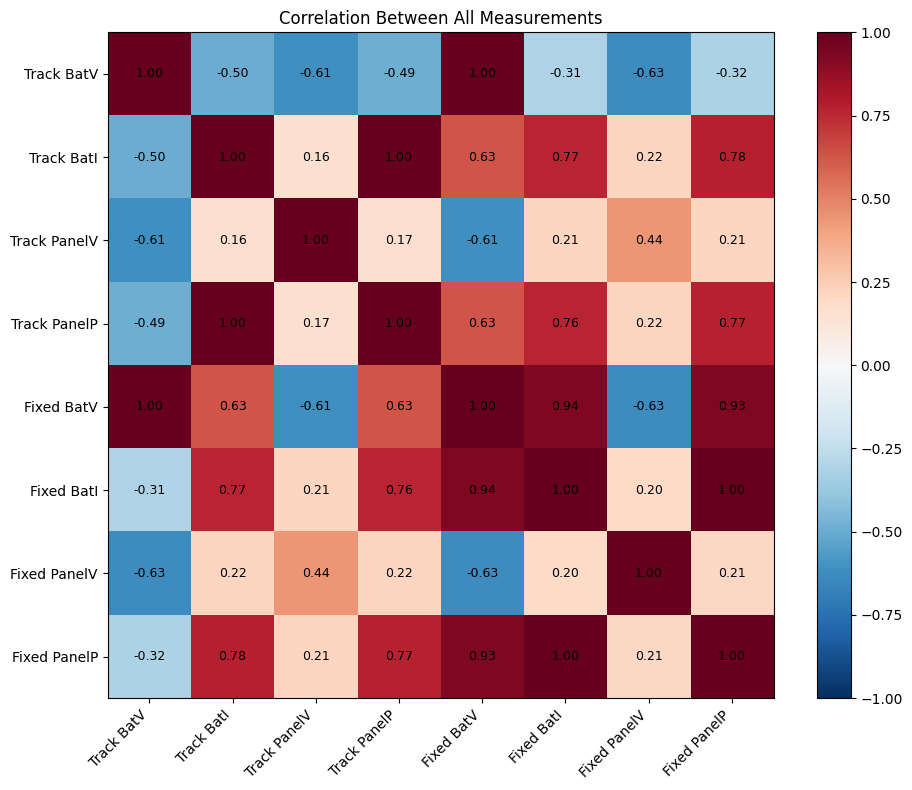

In [7]:
# Combine all Device 1 data and all Device 2 data for correlation analysis
all_d1 = pd.concat([d['dev1'] for d in all_data.values()], ignore_index=True)
all_d2 = pd.concat([d['dev2'] for d in all_data.values()], ignore_index=True)

# Rename columns for clarity
combined = pd.DataFrame({
    'Track BatV': all_d1['BatV'],
    'Track BatI': all_d1['BatI'],
    'Track PanelV': all_d1['PanelV'],
    'Track PanelP': all_d1['PanelP'],
    'Fixed BatV': all_d2['BatV'],
    'Fixed BatI': all_d2['BatI'],
    'Fixed PanelV': all_d2['PanelV'],
    'Fixed PanelP': all_d2['PanelP'],
})

fig, ax = plt.subplots(figsize=(10, 8))
corr = combined.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Add numbers in each cell
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

plt.colorbar(im)
plt.title('Correlation Between All Measurements')
plt.tight_layout()
plt.show()

## Power Distribution — Histogram
How often does each panel hit certain power levels?

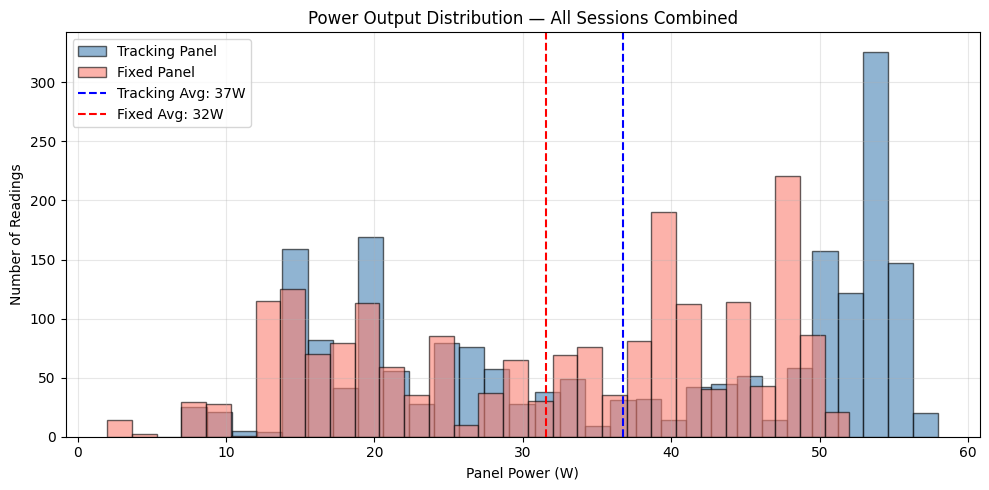


Tracking panel average: 36.8W (peak: 58W)
Fixed panel average:    31.6W (peak: 52W)
Overall tracking advantage: 16.4%


In [8]:
# Power distribution histograms
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_d1['PanelP'], bins=30, alpha=0.6, label='Tracking Panel', color='steelblue', edgecolor='black')
ax.hist(all_d2['PanelP'], bins=30, alpha=0.6, label='Fixed Panel', color='salmon', edgecolor='black')

ax.axvline(all_d1['PanelP'].mean(), color='blue', linestyle='--', label=f"Tracking Avg: {all_d1['PanelP'].mean():.0f}W")
ax.axvline(all_d2['PanelP'].mean(), color='red', linestyle='--', label=f"Fixed Avg: {all_d2['PanelP'].mean():.0f}W")

ax.set_xlabel('Panel Power (W)')
ax.set_ylabel('Number of Readings')
ax.set_title('Power Output Distribution — All Sessions Combined')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTracking panel average: {all_d1['PanelP'].mean():.1f}W (peak: {all_d1['PanelP'].max():.0f}W)")
print(f"Fixed panel average:    {all_d2['PanelP'].mean():.1f}W (peak: {all_d2['PanelP'].max():.0f}W)")
print(f"Overall tracking advantage: {((all_d1['PanelP'].mean() - all_d2['PanelP'].mean()) / all_d2['PanelP'].mean()) * 100:.1f}%")